In [ ]:
#EX1

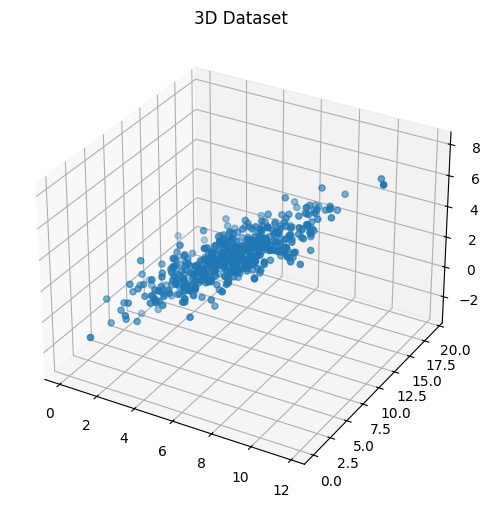

In [9]:
#Data generation and 3D visualization
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

mean_vec = np.array([5.0, 10.0, 2.0])
cov_mat = np.array([[3.0, 2.0, 2.0],
                    [2.0, 10.0, 1.0],
                    [2.0, 1.0, 2.0]])

samples = 500
X = np.random.multivariate_normal(mean_vec, cov_mat, size=samples)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], s=20)
ax.set_title("3D Dataset")
plt.show()


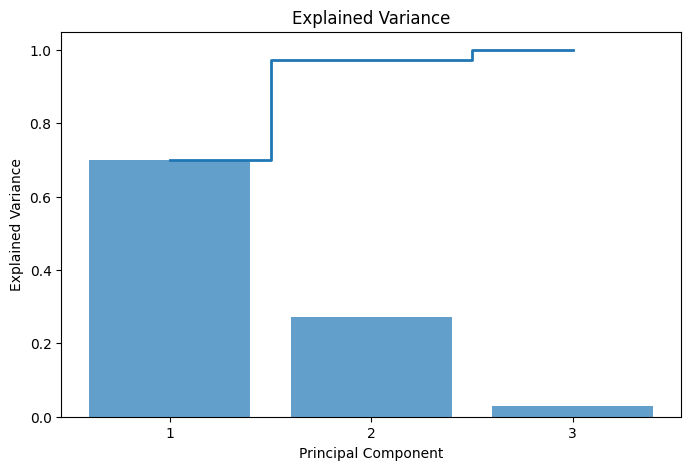

In [10]:
#PCA computation and variance analysis
Xc = X - X.mean(axis=0)
C = np.cov(Xc, rowvar=False)

e_vals, e_vecs = np.linalg.eigh(C)
order = np.argsort(e_vals)[::-1]

e_vals = e_vals[order]
e_vecs = e_vecs[:, order]

var_ratio = e_vals / e_vals.sum()
cum_var = np.cumsum(var_ratio)

plt.figure(figsize=(8,5))
plt.bar([1,2,3], var_ratio, alpha=0.7)
plt.step([1,2,3], cum_var, where="mid", linewidth=2)
plt.xticks([1,2,3])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Explained Variance")
plt.show()

Xp = Xc @ e_vecs


PC3 threshold: 1.0698767500350197
PC3 anomalies: 50
PC2 threshold: 3.1957026088655764
PC2 anomalies: 50
Full PCA-distance threshold: 6.0430876966986995
Full PCA-distance anomalies: 50


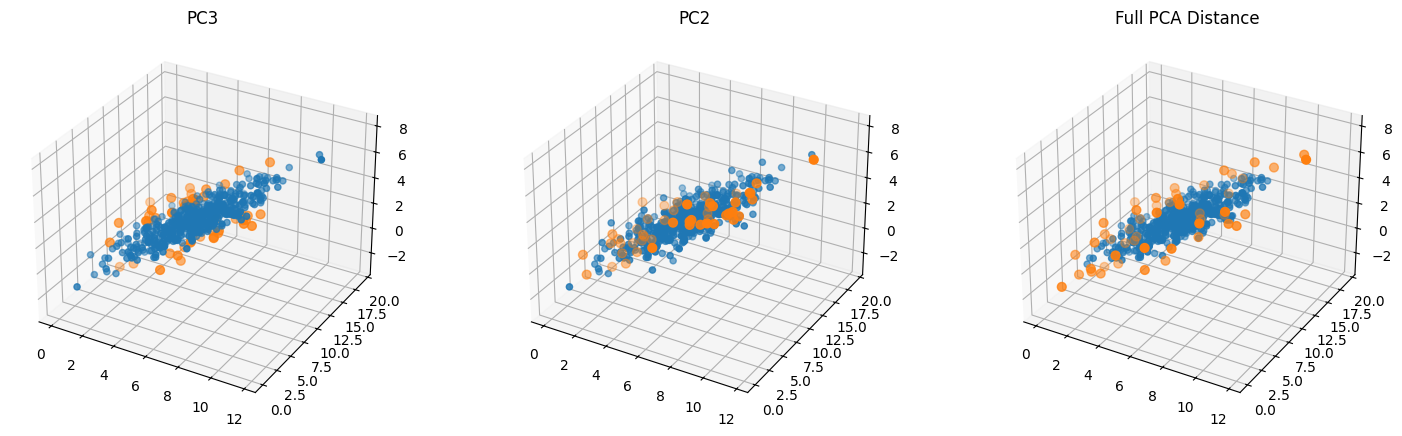

In [12]:
#Anomaly detection in PCA space (3 methods)
alpha = 0.1

pc3_dev = np.abs(Xp[:,2] - Xp[:,2].mean())
thr_pc3 = np.quantile(pc3_dev, 1 - alpha)
lab_pc3 = (pc3_dev > thr_pc3).astype(int)

pc2_dev = np.abs(Xp[:,1] - Xp[:,1].mean())
thr_pc2 = np.quantile(pc2_dev, 1 - alpha)
lab_pc2 = (pc2_dev > thr_pc2).astype(int)

Xp_scaled = Xp / np.sqrt(e_vals)
dist_full = np.sum(Xp_scaled**2, axis=1)
thr_full = np.quantile(dist_full, 1 - alpha)
lab_full = (dist_full > thr_full).astype(int)

print("PC3 threshold:", thr_pc3)
print("PC3 anomalies:", lab_pc3.sum())

print("PC2 threshold:", thr_pc2)
print("PC2 anomalies:", lab_pc2.sum())

print("Full PCA-distance threshold:", thr_full)
print("Full PCA-distance anomalies:", lab_full.sum())

fig = plt.figure(figsize=(18,5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(X[lab_pc3==0,0], X[lab_pc3==0,1], X[lab_pc3==0,2], s=20)
ax1.scatter(X[lab_pc3==1,0], X[lab_pc3==1,1], X[lab_pc3==1,2], s=40)
ax1.set_title("PC3")

ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(X[lab_pc2==0,0], X[lab_pc2==0,1], X[lab_pc2==0,2], s=20)
ax2.scatter(X[lab_pc2==1,0], X[lab_pc2==1,1], X[lab_pc2==1,2], s=40)
ax2.set_title("PC2")

ax3 = fig.add_subplot(133, projection="3d")
ax3.scatter(X[lab_full==0,0], X[lab_full==0,1], X[lab_full==0,2], s=20)
ax3.scatter(X[lab_full==1,0], X[lab_full==1,1], X[lab_full==1,2], s=40)
ax3.set_title("Full PCA Distance")

plt.show()

In [ ]:
#EX2

In [2]:
#Load data, split, standardize
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA
from pyod.utils.utility import standardizer

data = loadmat("shuttle.mat")
X = data["X"]
y = data["y"].ravel()

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, train_size=0.6, random_state=0, shuffle=True
)

X_tr_s, X_te_s = standardizer(X_tr, X_te)

cont = y_tr.mean()
cont

np.float64(0.07050716274017245)

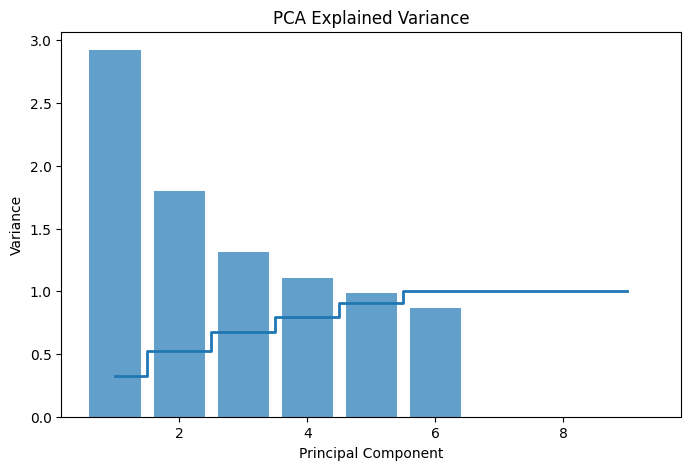

PCA Balanced Accuracy — Train: 0.9735827484194441
PCA Balanced Accuracy — Test : 0.972780593864162


In [3]:
#PCA fit and explained variance plots
pca_model = PCA(contamination=cont)
pca_model.fit(X_tr_s)

var = pca_model.explained_variance_
cum_var = np.cumsum(var) / np.sum(var)

plt.figure(figsize=(8,5))
plt.bar(range(1, len(var)+1), var, alpha=0.7)
plt.step(range(1, len(var)+1), cum_var, where="mid", linewidth=2)
plt.xlabel("Principal Component")
plt.ylabel("Variance")
plt.title("PCA Explained Variance")
plt.show()

#PCA balanced accuracy (train & test)
pred_tr = pca_model.predict(X_tr_s)
pred_te = pca_model.predict(X_te_s)

ba_tr = balanced_accuracy_score(y_tr, pred_tr)
ba_te = balanced_accuracy_score(y_te, pred_te)

print("PCA Balanced Accuracy — Train:", ba_tr)
print("PCA Balanced Accuracy — Test :", ba_te)

In [4]:
#KPCA fit and evaluation
idx = np.random.choice(len(X_tr_s), size=3000, replace=False) #Small sample so my kernel doesn't freeze
X_tr_k = X_tr_s[idx]
y_tr_k = y_tr[idx]

kpca_model = KPCA(contamination=y_tr_k.mean(), kernel="rbf")
kpca_model.fit(X_tr_k)

pred_tr_k = kpca_model.predict(X_tr_k)
pred_te_k = kpca_model.predict(X_te_s)

ba_tr_k = balanced_accuracy_score(y_tr_k, pred_tr_k)
ba_te_k = balanced_accuracy_score(y_te, pred_te_k)

print("KPCA Balanced Accuracy — Train:", ba_tr_k)
print("KPCA Balanced Accuracy — Test :", ba_te_k)

KPCA Balanced Accuracy — Train: 0.47255018397951914
KPCA Balanced Accuracy — Test : 0.7186455626816395


In [11]:
#EX3
#!pip install tensorflow

In [21]:
#Load data, split, min–max normalization
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import balanced_accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential

data = loadmat("shuttle.mat")
X = data["X"]
y = data["y"].astype(int).ravel()

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.5, random_state=0, shuffle=True
)

scaler = MinMaxScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

X_tr_s.shape, X_te_s.shape

((24548, 9), (24549, 9))

In [22]:
#Autoencoder model definition and compilation
class AE(Model):
    def __init__(self):
        super().__init__()
        self.enc = Sequential([
            layers.Dense(8, activation="relu"),
            layers.Dense(5, activation="relu"),
            layers.Dense(3, activation="relu")
        ])
        self.dec = Sequential([
            layers.Dense(5, activation="relu"),
            layers.Dense(8, activation="relu"),
            layers.Dense(9, activation="sigmoid")
        ])

    def call(self, x):
        z = self.enc(x)
        return self.dec(z)

model = AE()
model.compile(optimizer="adam", loss="mse")
#model.summary()

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0274 - val_loss: 0.0250
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0223 - val_loss: 0.0194
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0166 - val_loss: 0.0138
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0118 - val_loss: 0.0101
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0089 - val_loss: 0.0078
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - val_loss: 0.0062
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - val_loss: 0.0051
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

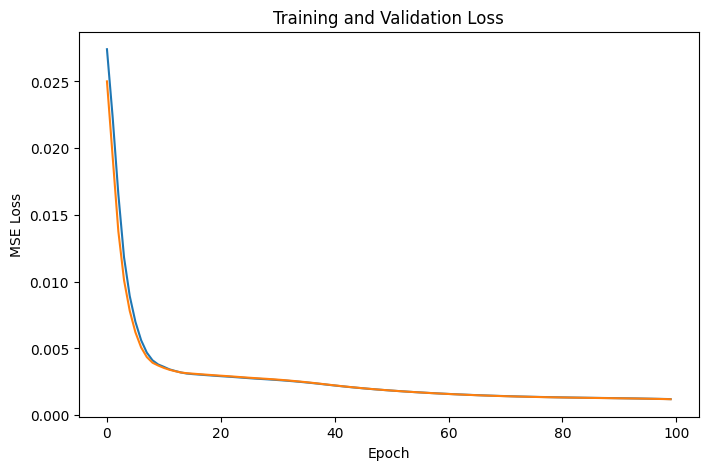

In [14]:
#Training and loss visualization
history = model.fit(
    X_tr_s,
    X_tr_s,
    epochs=100,
    batch_size=1024,
    validation_data=(X_te_s, X_te_s),
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.show()

In [23]:
#Reconstruction error, thresholding, balanced accuracy
rec_tr = model.predict(X_tr_s)
err_tr = np.mean((X_tr_s - rec_tr)**2, axis=1)

rec_te = model.predict(X_te_s)
err_te = np.mean((X_te_s - rec_te)**2, axis=1)

cont = np.mean(y_tr == 1)
thr = np.quantile(err_tr, 1 - cont)

pred_tr = (err_tr > thr).astype(int)
pred_te = (err_te > thr).astype(int)

ba_tr = balanced_accuracy_score(y_tr, pred_tr)
ba_te = balanced_accuracy_score(y_te, pred_te)

print("Threshold:", thr)
print("Balanced Accuracy (TRAIN):", ba_tr)
print("Balanced Accuracy (TEST):", ba_te)

768/768 ━━━━━━━━━━━━━━━━━━━━ 1s 599us/step
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step
Threshold: 0.043245705108252035
Balanced Accuracy (TRAIN): 0.6029279709078487
Balanced Accuracy (TEST): 0.6207033454510356


In [ ]:
#EX4

In [16]:
#Load MNIST, normalize, add noise
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.datasets import mnist

(X_tr, _), (X_te, _) = mnist.load_data()

X_tr = X_tr.astype("float32") / 255.0
X_te = X_te.astype("float32") / 255.0

X_tr = np.expand_dims(X_tr, -1)
X_te = np.expand_dims(X_te, -1)

noise_level = 0.35
X_te_noisy = X_te + noise_level * tf.random.normal(shape=X_te.shape)
X_te_noisy = tf.clip_by_value(X_te_noisy, 0.0, 1.0)

X_tr.shape, X_te.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((60000, 28, 28, 1), (10000, 28, 28, 1))

In [18]:
#Convolutional Autoencoder definition and compilation
class CAE(Model):
    def __init__(self):
        super().__init__()
        self.enc = Sequential([
            layers.Conv2D(8, (3,3), activation="relu", strides=2, padding="same"),
            layers.Conv2D(4, (3,3), activation="relu", strides=2, padding="same")
        ])
        self.dec = Sequential([
            layers.Conv2DTranspose(4, (3,3), activation="relu", strides=2, padding="same"),
            layers.Conv2DTranspose(8, (3,3), activation="relu", strides=2, padding="same"),
            layers.Conv2D(1, (3,3), activation="sigmoid", padding="same")
        ])

    def call(self, x):
        z = self.enc(x)
        return self.dec(z)

cae = CAE()
cae.compile(optimizer="adam", loss="mse")
#cae.summary()

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0267 - val_loss: 0.0047
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0040 - val_loss: 0.0033
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0022 - val_loss: 0.0021


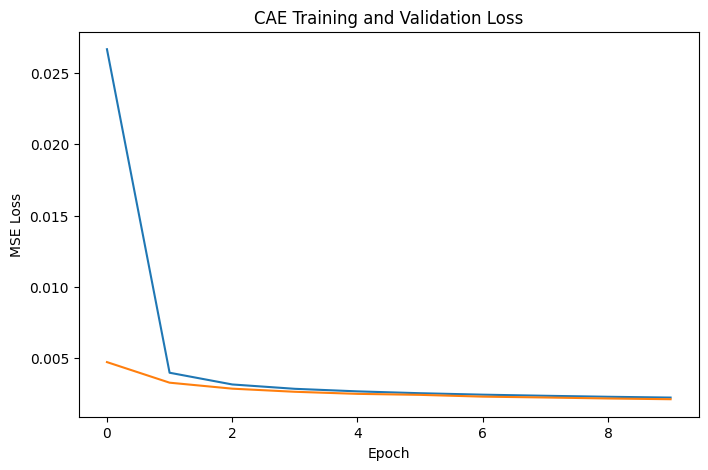

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Reconstruction threshold: 0.0032847316
Accuracy on clean test images: 0.8861
Accuracy on noisy test images: 1.0


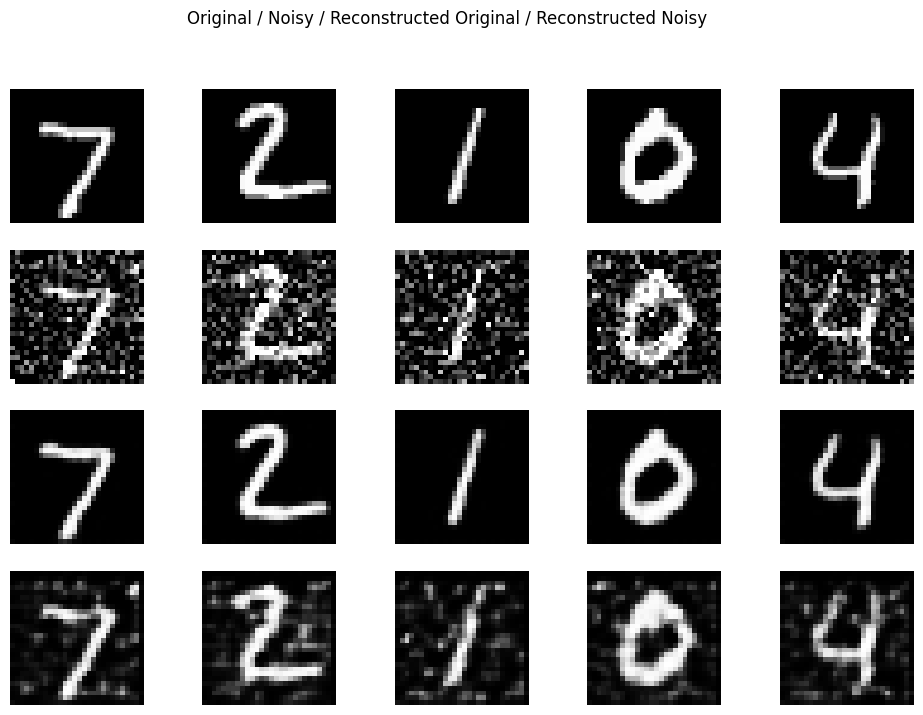

In [19]:
#Train CAE, thresholding, accuracy, visualization
hist = cae.fit(
    X_tr, X_tr,
    epochs=10,
    batch_size=64,
    validation_data=(X_te, X_te),
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CAE Training and Validation Loss")
plt.show()

rec_tr = cae.predict(X_tr)
err_tr = np.mean((X_tr - rec_tr)**2, axis=(1,2,3))

thr = err_tr.mean() + err_tr.std()

rec_te = cae.predict(X_te)
rec_te_noisy = cae.predict(X_te_noisy)

err_te = np.mean((X_te - rec_te)**2, axis=(1,2,3))
err_te_noisy = np.mean((X_te_noisy - rec_te_noisy)**2, axis=(1,2,3))

acc_clean = np.mean((err_te <= thr).astype(int))
acc_noisy = np.mean((err_te_noisy > thr).astype(int))

print("Reconstruction threshold:", thr)
print("Accuracy on clean test images:", acc_clean)
print("Accuracy on noisy test images:", acc_noisy)

k = 5
plt.figure(figsize=(12,8))

for i in range(k):
    plt.subplot(4, k, i+1)
    plt.imshow(X_te[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(4, k, i+1+k)
    plt.imshow(X_te_noisy[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(4, k, i+1+2*k)
    plt.imshow(rec_te[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(4, k, i+1+3*k)
    plt.imshow(rec_te_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Original / Noisy / Reconstructed Original / Reconstructed Noisy")
plt.show()


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0426 - val_loss: 0.0159
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0128 - val_loss: 0.0116
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0112 - val_loss: 0.0108
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0107 - val_loss: 0.0105
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0105 - val_loss: 0.0103
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0103 - val_loss: 0.0102
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0101 - val_loss: 0.0101
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0100 - val_loss: 0.0100
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0099 - val_loss: 0.0099
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0099 - val_loss: 0.0099
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


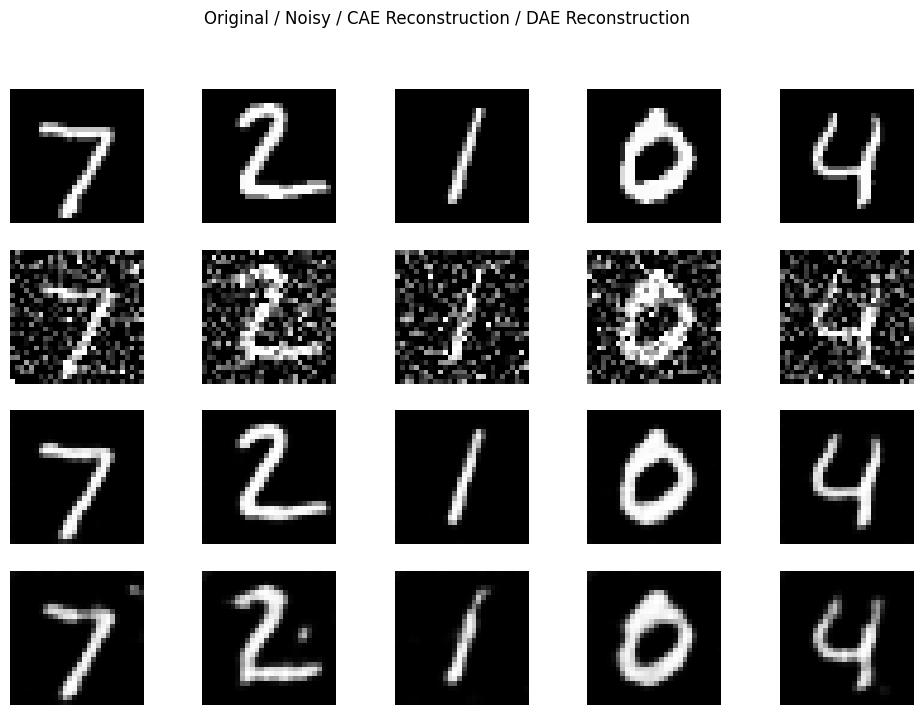

In [20]:
#Denoising Autoencoder training and visualization
dae = CAE()
dae.compile(optimizer="adam", loss="mse")

hist_d = dae.fit(
    X_tr + noise_level * tf.random.normal(shape=X_tr.shape),
    X_tr,
    epochs=10,
    batch_size=64,
    validation_data=(X_te_noisy, X_te),
    verbose=1
)

dae_rec_noisy = dae.predict(X_te_noisy)

plt.figure(figsize=(12,8))

for i in range(k):
    plt.subplot(4, k, i+1)
    plt.imshow(X_te[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(4, k, i+1+k)
    plt.imshow(X_te_noisy[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(4, k, i+1+2*k)
    plt.imshow(rec_te[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(4, k, i+1+3*k)
    plt.imshow(dae_rec_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Original / Noisy / CAE Reconstruction / DAE Reconstruction")
plt.show()
